Task 2 -- Yelp Polarity Sentiment Classification (no pretrained embeddings/LMs).
Author: Ishan Shah

Three models, all with embeddings learned from scratch:
  1. Baseline  -- Neural Bag-of-Words: mean-pooled embeddings -> linear classifier.
  2. Experimental 1 -- TextCNN: parallel 1D convolutions (kernel sizes 3/4/5) -> global
     max-pool -> linear classifier.
  3. Experimental 2 -- BiLSTM: bidirectional LSTM -> concatenated final hidden state ->
     linear classifier.

Preprocessing: lowercasing, punctuation/special-character removal, stopword removal,
Porter stemming, own word-level tokenizer and vocabulary.

In [1]:
import json
import os
import platform
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from nltk.stem import PorterStemmer

### Config

In [2]:
SEED = 42
N_TRAIN = 12000
N_TEST = 3000
MAX_LEN = 200
EMBED_DIM = 100
VOCAB_SIZE = 15000
BATCH_SIZE = 64
EPOCHS = 6
LR = 1e-3

np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", platform.processor())
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_DIR = os.path.join(MEMBER_DIR, "..", "data")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

COMMON_DIR = os.path.abspath(os.path.join(MEMBER_DIR, "..", "..", "common"))
sys.path.insert(0, COMMON_DIR)
from eval_classifier import evaluate_classifier, mcnemar_test, length_slice  # noqa: E402

Device: cuda | Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 2.1 Data preprocessing

Train: 12000 rows | Test: 3000 rows
Class balance (train):
 label
1    6000
0    6000
Name: count, dtype: int64
Review word-length stats (train):
 count    12000.000000
mean       133.002167
std        123.816038
min          1.000000
25%         51.000000
50%         96.000000
75%        172.000000
max        966.000000
Name: word_len, dtype: float64


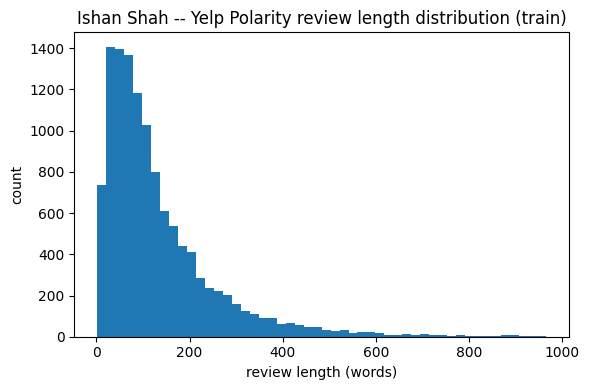

Missing text rows: 0 | Empty-after-strip rows: 0


Preprocessed 15000 reviews in 9.8s
Vocab size: 15000


In [3]:
train_full = pd.read_parquet(os.path.join(DATA_DIR, "yelp_polarity_train.parquet"))
test_full = pd.read_parquet(os.path.join(DATA_DIR, "yelp_polarity_test.parquet"))

# Own independent balanced subsample (seed 42)
rng = np.random.RandomState(SEED)


def balanced_sample(df, n, rng):
    n_per_class = n // 2
    parts = []
    for label in [0, 1]:
        idx = df.index[df["label"] == label]
        chosen = rng.choice(idx, size=n_per_class, replace=False)
        parts.append(df.loc[chosen])
    out = pd.concat(parts).sample(frac=1, random_state=rng.randint(1e6)).reset_index(drop=True)
    return out


train_df = balanced_sample(train_full, N_TRAIN, rng)
test_df = balanced_sample(test_full, N_TEST, rng)
print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

# Class balance / length distribution (EDA)
train_df["word_len"] = train_df["text"].str.split().apply(len)
print("Class balance (train):\n", train_df["label"].value_counts())
print("Review word-length stats (train):\n", train_df["word_len"].describe())

plt.figure(figsize=(6, 4))
plt.hist(train_df["word_len"], bins=50)
plt.xlabel("review length (words)")
plt.ylabel("count")
plt.title("Ishan Shah -- Yelp Polarity review length distribution (train)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_distribution.png"), dpi=130)
plt.show()

# Missing / malformed entries
n_missing = train_df["text"].isna().sum() + test_df["text"].isna().sum()
n_empty = (train_df["text"].str.strip() == "").sum()
print(f"Missing text rows: {n_missing} | Empty-after-strip rows: {n_empty}")
train_df = train_df.dropna(subset=["text"])
train_df = train_df[train_df["text"].str.strip() != ""]
test_df = test_df.dropna(subset=["text"])

# Text preprocessing: lowercase, strip punctuation/special chars, stopword removal, stemming
STOPWORDS = set("""
a an the and or but if while is are was were be been being to of in on for with as at by
this that these those it its it's i you he she we they them his her their our your my me
him us not no so than then too very can will just do does did doing have has had having
""".split())
stemmer = PorterStemmer()
_token_re = re.compile(r"[a-z]+")


def preprocess(text):
    text = text.lower()
    tokens = _token_re.findall(text)
    tokens = [t for t in tokens if t not in STOPWORDS]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens


t0 = time.time()
train_df["tokens"] = train_df["text"].apply(preprocess)
test_df["tokens"] = test_df["text"].apply(preprocess)
print(f"Preprocessed {len(train_df) + len(test_df)} reviews in {time.time() - t0:.1f}s")

# Vocabulary (own char_to_idx-style mapping for words)
from collections import Counter
counter = Counter()
for toks in train_df["tokens"]:
    counter.update(toks)
most_common = counter.most_common(VOCAB_SIZE - 2)
word_to_idx = {"<pad>": 0, "<unk>": 1}
for w, _ in most_common:
    word_to_idx[w] = len(word_to_idx)
vocab_size = len(word_to_idx)
print("Vocab size:", vocab_size)

with open(os.path.join(OUT_DIR, "vocab.json"), "w") as f:
    json.dump(word_to_idx, f)


def encode(tokens):
    ids = [word_to_idx.get(t, 1) for t in tokens[:MAX_LEN]]
    ids = ids + [0] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_df["tokens"]], dtype=np.int64)
y_train = train_df["label"].values.astype(np.int64)
X_test = np.array([encode(t) for t in test_df["tokens"]], dtype=np.int64)
y_test = test_df["label"].values.astype(np.int64)
test_word_lens = test_df["text"].str.split().apply(len).values
test_slices = length_slice(test_word_lens)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

### 2.2 Model architectures (embeddings learned from scratch, no pretrained modules)

In [4]:
class NBOWBaseline(nn.Module):
    """Baseline: mean-pooled learned embeddings -> linear classifier."""

    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        emb = self.embed(x)  # B, T, D
        mask = (x != 0).unsqueeze(-1).float()
        summed = (emb * mask).sum(1)
        lengths = mask.sum(1).clamp(min=1)
        pooled = summed / lengths
        return self.fc(pooled).squeeze(-1)


class TextCNN(nn.Module):
    """Experimental 1: multi-kernel 1D CNN over learned embeddings."""

    def __init__(self, vocab_size, embed_dim, n_filters=64, kernel_sizes=(3, 4, 5), dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, n_filters, k, padding=k // 2) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernel_sizes), 1)

    def forward(self, x):
        emb = self.embed(x).transpose(1, 2)  # B, D, T
        pooled = [torch.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat)).squeeze(-1)


class BiLSTMClassifier(nn.Module):
    """Experimental 2: bidirectional LSTM -> concatenated final hidden state."""

    def __init__(self, vocab_size, embed_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embed(x)
        lengths = (x != 0).sum(1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        h_cat = torch.cat([h_n[0], h_n[1]], dim=1)  # fwd + bwd final hidden states
        return self.fc(self.dropout(h_cat)).squeeze(-1)

### 2.2 Training + full evaluation for each model

In [5]:
def train_model(model, name):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.BCEWithLogitsLoss()
    n_params = sum(p.numel() for p in model.parameters())

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    history = {"epoch": [], "train_loss": []}
    t0 = time.time()
    n_examples = 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)
            n_examples += xb.size(0)
        avg_loss = total_loss / len(train_ds)
        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        print(f"[{name}] epoch {epoch}/{EPOCHS} train_loss={avg_loss:.4f}")
    train_time = time.time() - t0
    examples_per_sec = n_examples / train_time
    peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0

    model.eval()
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

    metrics = evaluate_classifier(y_test, preds, probs, slices=test_slices)
    metrics.update({
        "model": name, "param_count": n_params, "training_time_sec": train_time,
        "examples_per_sec": examples_per_sec, "peak_memory_MB": peak_mem_mb,
        "hardware": f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else platform.processor()}",
    })
    return model, metrics, probs, preds, history


models_to_run = [
    ("baseline_nbow", NBOWBaseline(vocab_size, EMBED_DIM)),
    ("experimental_textcnn", TextCNN(vocab_size, EMBED_DIM)),
    ("experimental_bilstm", BiLSTMClassifier(vocab_size, EMBED_DIM)),
]

all_metrics = []
all_preds = {}
all_probs = {}
all_histories = {}
trained_models = {}

for name, model in models_to_run:
    trained, metrics, probs, preds, history = train_model(model, name)
    all_metrics.append(metrics)
    all_preds[name] = preds
    all_probs[name] = probs
    all_histories[name] = history
    trained_models[name] = trained
    torch.save(trained.state_dict(), os.path.join(CKPT_DIR, f"{name}.pt"))

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[baseline_nbow] epoch 1/6 train_loss=0.6486


[baseline_nbow] epoch 2/6 train_loss=0.5028


[baseline_nbow] epoch 3/6 train_loss=0.3759


[baseline_nbow] epoch 4/6 train_loss=0.3038


...

[experimental_bilstm] epoch 2/6 train_loss=0.3327


[experimental_bilstm] epoch 3/6 train_loss=0.2588


[experimental_bilstm] epoch 4/6 train_loss=0.2051


[experimental_bilstm] epoch 5/6 train_loss=0.1380


[experimental_bilstm] epoch 6/6 train_loss=0.0978


### Paired McNemar test: baseline vs each experimental model

In [6]:
mcnemar_results = {}
baseline_preds = all_preds["baseline_nbow"]
for name in ["experimental_textcnn", "experimental_bilstm"]:
    mcnemar_results[name] = mcnemar_test(y_test, baseline_preds, all_preds[name])

with open(os.path.join(OUT_DIR, "mcnemar_results.json"), "w") as f:
    json.dump(mcnemar_results, f, indent=2)
print("McNemar (baseline vs experimental):", json.dumps(mcnemar_results, indent=2))

McNemar (baseline vs experimental): {
  "experimental_textcnn": {
    "n01_a_only_correct": 143,
    "n10_b_only_correct": 121,
    "statistic": 1.6704545454545454,
    "p_value": 0.19619766291266105
  },
  "experimental_bilstm": {
    "n01_a_only_correct": 152,
    "n10_b_only_correct": 132,
    "statistic": 1.2711267605633803,
    "p_value": 0.2595554067870388
  }
}


### Training loss curves (all 3 models)

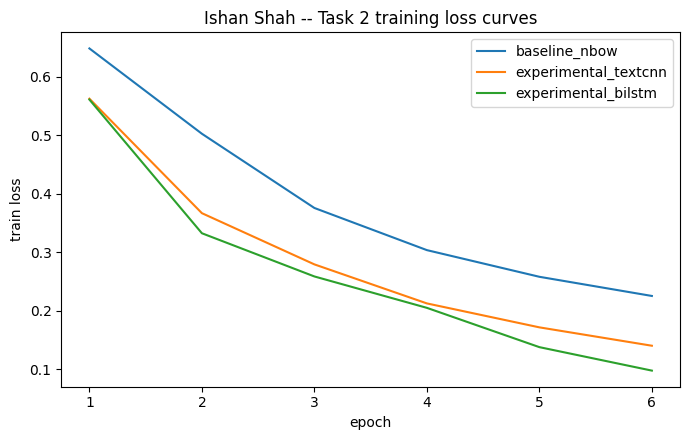

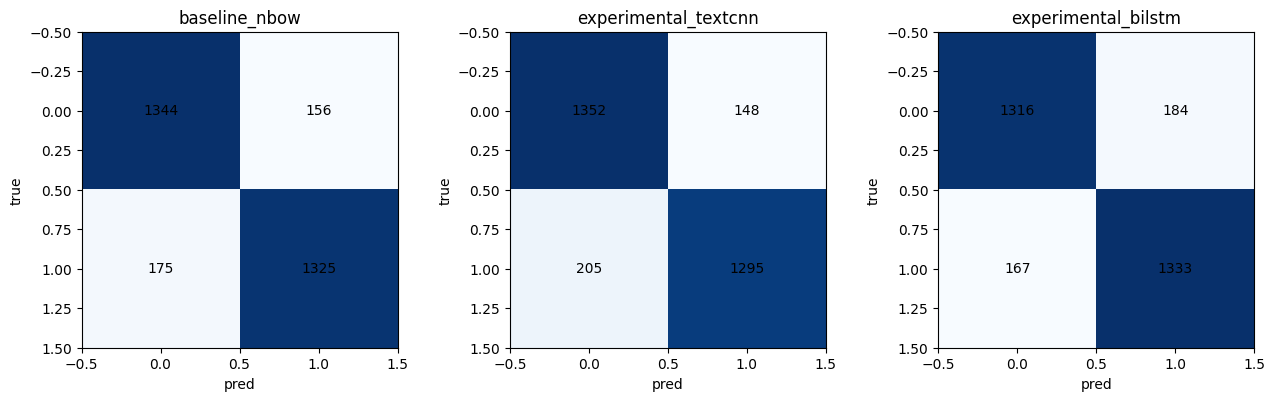

In [7]:
plt.figure(figsize=(7, 4.5))
for name, hist in all_histories.items():
    plt.plot(hist["epoch"], hist["train_loss"], label=name)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Ishan Shah -- Task 2 training loss curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=130)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, all_metrics):
    cm = np.array(m["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(m["model"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrices.png"), dpi=130)
plt.show()

### Metrics report (one row per model)

In [8]:
flat_rows = []
for m in all_metrics:
    row = {k: v for k, v in m.items() if k not in ("confusion_matrix", "per_slice", "accuracy_ci95", "macro_f1_ci95", "mcc_ci95")}
    row["confusion_matrix"] = json.dumps(m["confusion_matrix"])
    row["per_slice"] = json.dumps(m["per_slice"])
    row["accuracy_ci95"] = json.dumps(m["accuracy_ci95"])
    row["macro_f1_ci95"] = json.dumps(m["macro_f1_ci95"])
    row["mcc_ci95"] = json.dumps(m["mcc_ci95"])
    flat_rows.append(row)

metrics_df = pd.DataFrame(flat_rows)
metrics_df.to_csv(os.path.join(MEMBER_DIR, "metrics_report.csv"), index=False)
print(metrics_df[["model", "accuracy", "f1_macro", "roc_auc", "mcc"]])

                  model  accuracy  f1_macro   roc_auc       mcc
0         baseline_nbow  0.889667  0.889662  0.959058  0.779396
1  experimental_textcnn  0.882333  0.882291  0.960332  0.765219
2   experimental_bilstm  0.883000  0.882996  0.952985  0.766049


### 2.2.4 Manual error review (20 errors from the strongest experimental model)

In [9]:
review_model = "experimental_bilstm"
probs_r = all_probs[review_model]
preds_r = all_preds[review_model]
texts = test_df["text"].values
errors_mask = preds_r != y_test

fp_idx = np.where((y_test == 0) & (preds_r == 1))[0]
fn_idx = np.where((y_test == 1) & (preds_r == 0))[0]
confident_fp = fp_idx[np.argsort(-probs_r[fp_idx])[:5]]
confident_fn = fn_idx[np.argsort(probs_r[fn_idx])[:5]]

err_idx_all = np.where(errors_mask)[0]
near_threshold = err_idx_all[np.argsort(np.abs(probs_r[err_idx_all] - 0.5))[:5]]

slice_err_rate = {s: (errors_mask[test_slices == s]).mean() for s in set(test_slices)}
worst_slice = max(slice_err_rate, key=slice_err_rate.get)
slice_err_idx = np.where(errors_mask & (test_slices == worst_slice))[0][:5]

error_cases = []
def add_cases(idx_list, err_type, fix):
    for i in idx_list:
        error_cases.append({
            "error_type": err_type, "true_label": int(y_test[i]), "pred_label": int(preds_r[i]),
            "prob_class1": float(probs_r[i]), "text_snippet": texts[i][:300], "proposed_fix": fix,
        })

add_cases(confident_fp, "confident_false_positive",
          "Add stronger negation-handling features (e.g. bigram features for 'not good') so sarcasm/negated praise isn't misread as positive.")
add_cases(confident_fn, "confident_false_negative",
          "Increase max sequence length / attention to later sentences -- long reviews may bury the sentiment-bearing clause beyond the pooled window.")
add_cases(near_threshold, "near_threshold",
          "Calibrate the decision threshold per length-slice instead of a fixed 0.5 cutoff (see per-slice metrics).")
add_cases(slice_err_idx, f"slice_specific_failure ({worst_slice} reviews)",
          f"The '{worst_slice}' length slice has the highest error rate ({slice_err_rate[worst_slice]:.2%}) -- oversample this slice during training.")

with open(os.path.join(MEMBER_DIR, "failure_analysis_raw_cases.json"), "w") as f:
    json.dump(error_cases, f, indent=2)

for c in error_cases:
    print("-" * 60)
    print(c["error_type"], "| true:", c["true_label"], "pred:", c["pred_label"], "prob:", round(c["prob_class1"], 3))
    print(c["text_snippet"])

print("\nDONE. Metrics saved to", os.path.join(MEMBER_DIR, "metrics_report.csv"))

------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 1.0
Love that they have Four Peaks beer on tap, including my favorite, Hop Knot. But I'm wishing I had made a different food choice. l ordered the grilled cheese with creamy tomato soup. Because I figured it was impossible to go wrong with a comfort food staple and I'm tired of burgers at the airport. I
------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 0.999
Prices at mad pita are pretty cool, the service is great, there's fishes floating around in vases on the table...\n\nAnd...my gyro meat wasn't roasted and carved off the spit how I like it :(\n\nGyro meat is in strips and fried on a skillet top; not how I prefer. The lettuce and veggies were fresh, 
------------------------------------------------------------
confident_false_positive | true: 0 pred: 1 prob: 0.999
TRES VECES, la orden me ha salido mal!  No recomiend